In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split

In [2]:
%load_ext autoreload
%autoreload 2
    
from vae import VAE

In [3]:
df = pd.read_csv('dataset/gdsc/exp.csv.gz', index_col=0)
df

,A1BG,A1CF,A2M,A2ML1,A4GALT,AADAC,AADAT,AAMDC,AARD,AASS,...,ZNRF1,ZNRF3,ZP3,ZSCAN16,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZWINT,ZYX
1240121,0.339974,-0.134210,-0.355801,0.153685,1.440833,-0.331754,-0.704305,-1.691068,-0.330709,0.657685,...,-0.223181,-0.752625,1.194265,-0.335577,-0.726587,0.425547,-0.298837,0.674141,-0.894967,0.061661
1240122,-0.206343,-0.321519,-0.454970,6.562916,-0.230353,-0.363170,0.278443,-1.810932,-0.200803,-0.914611,...,-0.049129,-0.750682,1.064771,-0.827131,-0.391908,-0.330118,-0.647183,0.204954,0.197851,-0.598001
1240123,-0.796043,3.275579,-0.233277,-0.166684,-1.415383,-0.174504,-1.157096,-0.187764,-0.221570,-0.803604,...,0.033635,1.301943,0.491792,0.575152,-1.171501,0.321854,3.571441,-0.564238,1.392452,-0.323448
1240125,0.575801,-0.198913,0.348788,-0.358565,-0.683234,-0.274522,-0.553155,-0.175391,0.080745,0.666923,...,-1.270085,0.400413,-0.054072,-1.507854,-1.213952,-1.236961,0.073607,0.203281,-0.675965,0.313539
1240127,0.793076,-0.393730,-0.501831,-0.178046,0.884821,-0.472541,0.182855,0.370835,-0.328202,0.161762,...,-0.203885,1.487751,0.676292,1.019452,0.682361,-0.437988,0.477985,-0.869309,0.783501,0.781815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971773,1.040774,-0.275320,0.669137,0.059725,-0.171409,-0.477549,-0.213272,0.605488,0.668279,2.124183,...,-1.451891,-0.611205,2.487295,-0.280620,0.742546,-1.001595,-0.870108,1.238322,-0.609764,0.157902
971774,0.699240,-0.102069,-0.270735,0.243411,0.736905,-0.464078,0.898634,0.011531,0.298060,-0.948458,...,0.113975,0.213413,-0.883517,-0.139339,1.405236,-0.602053,-0.580510,0.819847,0.999549,0.198345
971777,0.339472,-0.160107,3.276993,-0.101418,-0.372420,-0.249130,0.089344,-0.517937,-0.344582,0.387317,...,-0.578994,0.359013,-1.492978,-0.826358,-1.042803,-1.175224,-0.471456,-0.680010,0.301219,2.753435
998184,0.674628,-0.292559,-0.425120,-0.527079,-1.235471,-0.471083,1.303399,-0.555093,0.078891,0.626667,...,2.950797,-0.323017,-1.098421,-1.906059,0.105458,0.113064,0.217951,-0.332934,1.064759,-0.660269


In [4]:
# ---- Data Prep ----
input_data = torch.tensor(df.values, dtype=torch.float32)
n_samples, input_dim = input_data.shape

# train / val split
train_data, val_data = train_test_split(input_data, test_size=0.2, random_state=42)
train_loader = DataLoader(TensorDataset(train_data), batch_size=len(train_data), shuffle=True)
val_loader   = DataLoader(TensorDataset(val_data),   batch_size=len(val_data),   shuffle=False)

In [5]:
train_data.shape

torch.Size([753, 6254])

In [6]:
val_data.shape

torch.Size([189, 6254])

In [7]:
# ---- model/optimizer ----
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = "mps"
else:
    device = "cpu"
model = VAE(input_dim=input_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [8]:
# ---- log containers ----
history = {
    "train_loss": [], "val_loss": [],
    "train_recon": [], "val_recon": [],
    "train_kld": [], "val_kld": []
}

num_epochs = 300
C_max = 10.0
T = 200

for epoch in range(num_epochs):
    beta = min(1.0, epoch/50)
    C    = min(C_max, C_max * epoch / T)   # <- use C_max consistently
    margin = 2.0                          

    # ===== Train =====
    model.train()
    train_loss = train_recon = train_kld = 0.0   # ← エポック毎に初期化
    for (x,) in train_loader:
        x = x.to(device)
        x, xrec, mu, logvar = model(x)
        loss_dict = model.loss_function(x, xrec, mu, logvar, beta=beta, capacity=C, margin=margin)
        loss = loss_dict["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bsz = x.size(0)
        train_loss  += loss.item() * bsz
        train_recon += loss_dict["recons_loss"].item() * bsz
        train_kld   += loss_dict["KLD"].item() * bsz

    n_train = len(train_loader.dataset)
    train_loss  /= n_train
    train_recon /= n_train
    train_kld   /= n_train

    # ===== Validation =====
    model.eval()
    val_loss = val_recon = val_kld = 0.0
    with torch.no_grad():
        for (x,) in val_loader:
            x = x.to(device)
            x, xrec, mu, logvar = model(x)
            # pass margin here too
            loss_dict = model.loss_function(x, xrec, mu, logvar,
                                            beta=beta, capacity=C, margin=margin)
            loss = loss_dict["loss"]

            bsz = x.size(0)
            val_loss  += loss.item() * bsz
            val_recon += loss_dict["recons_loss"].item() * bsz
            val_kld   += loss_dict["KLD"].item() * bsz

    n_val = len(val_loader.dataset)
    val_loss  /= n_val
    val_recon /= n_val
    val_kld   /= n_val

    # ---- save to history ----
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_recon"].append(train_recon)
    history["val_recon"].append(val_recon)
    history["train_kld"].append(train_kld)
    history["val_kld"].append(val_kld)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train L:{train_loss:.4f} (Rec:{train_recon:.4f}, KL:{train_kld:.4f}) | "
            f"Val L:{val_loss:.4f} (Rec:{val_recon:.4f}, KL:{val_kld:.4f}) "
            f"| beta={beta:.2f} C={C:.2f}"
        )

Epoch   0 | Train L:0.9934 (Rec:0.9934, KL:1.1925) | Val L:1.0415 (Rec:1.0415, KL:1.0217) | beta=0.00 C=0.00
Epoch  10 | Train L:0.9911 (Rec:0.9911, KL:1.1864) | Val L:1.0405 (Rec:1.0405, KL:0.9224) | beta=0.20 C=0.50
Epoch  20 | Train L:0.9908 (Rec:0.9908, KL:0.9224) | Val L:1.0404 (Rec:1.0404, KL:0.8113) | beta=0.40 C=1.00
Epoch  30 | Train L:0.9906 (Rec:0.9906, KL:1.0300) | Val L:1.0404 (Rec:1.0404, KL:0.9059) | beta=0.60 C=1.50
Epoch  40 | Train L:0.9905 (Rec:0.9905, KL:1.1127) | Val L:1.0405 (Rec:1.0405, KL:0.9736) | beta=0.80 C=2.00
Epoch  50 | Train L:0.9903 (Rec:0.9903, KL:1.2029) | Val L:1.0406 (Rec:1.0406, KL:1.0608) | beta=1.00 C=2.50
Epoch  60 | Train L:0.9900 (Rec:0.9900, KL:1.4071) | Val L:1.0409 (Rec:1.0409, KL:1.2554) | beta=1.00 C=3.00
Epoch  70 | Train L:0.9889 (Rec:0.9889, KL:1.9969) | Val L:1.0407 (Rec:1.0407, KL:1.8520) | beta=1.00 C=3.50
Epoch  80 | Train L:0.9824 (Rec:0.9824, KL:4.7048) | Val L:1.0352 (Rec:1.0352, KL:4.5747) | beta=1.00 C=4.00
Epoch  90 | Train L

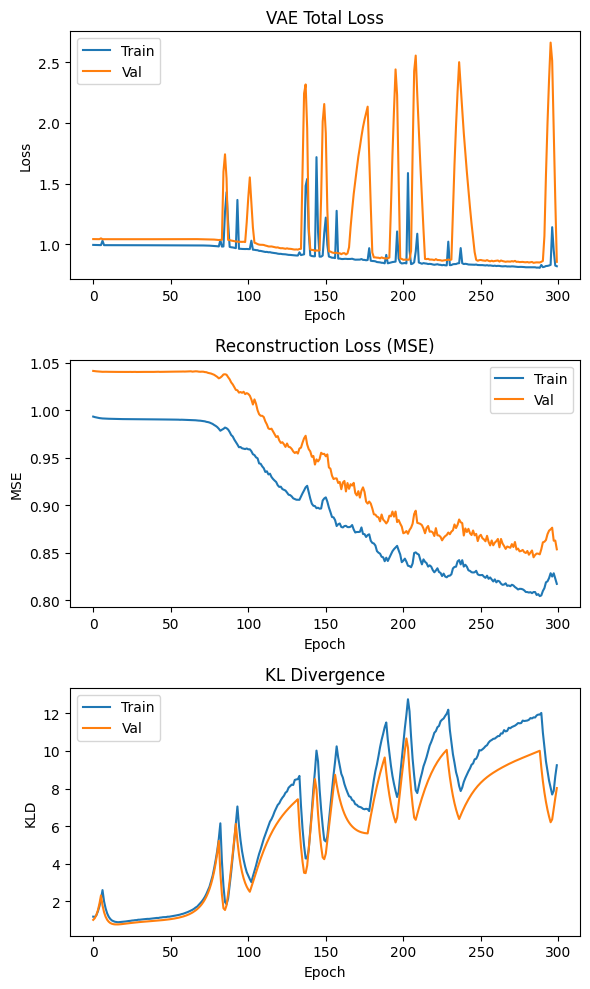

In [9]:
loss_keys = [
    ("train_loss", "val_loss", "VAE Total Loss", "Loss"),
    ("train_recon", "val_recon", "Reconstruction Loss (MSE)", "MSE"),
    ("train_kld", "val_kld", "KL Divergence", "KLD")
]

plt.figure(figsize=(6, 10))
for i, (train_key, val_key, title, ylabel) in enumerate(loss_keys, 1):
    plt.subplot(3, 1, i)
    plt.plot(history[train_key], label="Train")
    plt.plot(history[val_key], label="Val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# torch.save(model.state_dict(), "models/vae_gdsc.pt")